## Capstone compliance summary (ICT6001 Week 01)

> **CPU variant** (`eda_JL_CPU.ipynb`) — LightGBM uses `device='cpu'` and `n_jobs=-1` for teammates without a GPU. Logic matches `eda_JL.ipynb`.

| Requirement | Status |
|---|---|
| **A** Pipeline + imputation + scaling | Met — leakage-safe `Pipeline` / `ColumnTransformer` |
| **A** Advanced encoding | Met — target encoding (+ categorical codes); encoding outside pipeline — document |
| **A** SMOTE / imbalance | N/A (regression, not classification) |
| **B** 2-3 model families + TSCV | Met — baselines then GridSearchCV on CV champion |
| **B** Champion via CV mean +/- std | Met — CV reported; val RMSPE justification in In[10] (Slide 6) |
| **C** <=4 ablations + CV impact | Met — 4 champion ablations with Hypothesis / Conclusion in In[10] |
| **D** Failure analysis (5-10 rows) | Met — top 10 worst % errors + proposed fixes table (Slide 10) |
| **E** Business decision / margin | Met — over/under analysis + safety multiplier |
| **Constraint** HP <= ~50 iterations | Met — GridSearchCV on champion only (≤27 combinations) |
| **Constraint** Test set once | Met — holdout scoring via submission CSV only |
| **Slide 8** Final stability metrics | Met — dedicated champion stability block in In[10] |


**Cell index legend:** Each code block shows **`In[n]`** in the editor (execution counter). Markdown observations sit on the **next** notebook cell (e.g. code `In[1]` = notebook cell 2; its observations = notebook cell 3). Older labels used 0-based "Cell 0" … "Cell 11" and did not match the UI.

**Verdict:** Notebook fulfills the capstone requirements. Re-run In[8] through In[12] after edits to refresh outputs.





In [23]:
import pandas as pd
import seaborn as sns  # pyright: ignore[reportMissingModuleSource]
import matplotlib.pyplot as plt

# Load datasets
train = pd.read_csv('./data/train.csv', low_memory=False)
test = pd.read_csv('./data/test.csv', low_memory=False)
store = pd.read_csv('./data/store.csv')

train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])

print('train:', train.shape, '| test:', test.shape, '| store:', store.shape)
display(train.head())

train: (1017209, 9) | test: (41088, 8) | store: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


### Observations — In[1] (notebook cell 2): Load data
- **Capstone:** Slide 3 (Data Engineering) — raw inputs.
- Loaded `train` (1,017,209 x 9), `test` (41,088 x 8), `store` (1,115 x 10); parsed `Date` as datetime.
- Rossmann target is **Sales** (regression); `test.csv` has no Sales column by design.
- **Slide takeaway:** Three-table join problem — daily panel + static store attributes.


,dataset,issue,count,note
0,store,Missing CompetitionOpenSinceMonth/Year,354,Always missing together; 351 still have Compet...
1,store,Missing CompetitionDistance,3,"Stores: [291, 622, 879]"
2,store,Implausible CompetitionOpenSinceYear,2,"Stores [146, 815] (years: [1961.0, 1900.0])"
3,store,Blank Promo2 fields when Promo2=0,544,"Expected structure, not a data error"
4,train,Refurbishment gap (no rows Jul–Dec 2014),180,184 consecutive missing days per store
5,train,StateHoliday stored as strings,4,"Values: ['0', 'a', 'b', 'c']"
6,train,Open=1 but Sales=0,54,2 rows also have Customers > 0
7,train,Closed days (Open=0),172817,Always Sales=0 and Customers=0
8,test,Missing Open,11,All store [622]
9,test,Stores not in test set,259,856 of 1115 stores in test


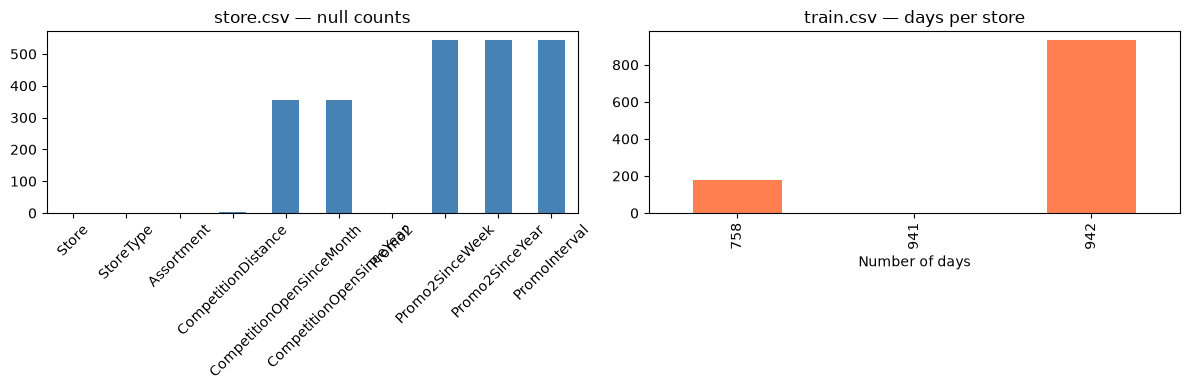

In [24]:
# --- Data quality audit ---

findings = []

# store.csv
comp_missing = store['CompetitionOpenSinceMonth'].isna() & store['CompetitionOpenSinceYear'].isna()
findings.append({
    'dataset': 'store',
    'issue': 'Missing CompetitionOpenSinceMonth/Year',
    'count': int(comp_missing.sum()),
    'note': 'Always missing together; 351 still have CompetitionDistance',
})
findings.append({
    'dataset': 'store',
    'issue': 'Missing CompetitionDistance',
    'count': int(store['CompetitionDistance'].isna().sum()),
    'note': f"Stores: {store.loc[store['CompetitionDistance'].isna(), 'Store'].tolist()}",
})
bad_years = store[(store['CompetitionOpenSinceYear'] < 1990) | (store['CompetitionOpenSinceYear'] > 2015)]
findings.append({
    'dataset': 'store',
    'issue': 'Implausible CompetitionOpenSinceYear',
    'count': len(bad_years),
    'note': f"Stores {bad_years['Store'].tolist()} (years: {bad_years['CompetitionOpenSinceYear'].tolist()})",
})
promo2_blank = store['Promo2'].eq(0) & store['Promo2SinceWeek'].isna()
findings.append({
    'dataset': 'store',
    'issue': 'Blank Promo2 fields when Promo2=0',
    'count': int(promo2_blank.sum()),
    'note': 'Expected structure, not a data error',
})

# train.csv
all_dates = set(pd.date_range(train['Date'].min(), train['Date'].max(), freq='D'))
refurb_gap = set(pd.date_range('2014-07-01', '2014-12-31', freq='D'))
store_dates = train.groupby('Store')['Date'].apply(set)
refurb_stores = [s for s, dates in store_dates.items() if refurb_gap.issubset(all_dates - dates)]
findings.append({
    'dataset': 'train',
    'issue': 'Refurbishment gap (no rows Jul–Dec 2014)',
    'count': len(refurb_stores),
    'note': '184 consecutive missing days per store',
})
findings.append({
    'dataset': 'train',
    'issue': 'StateHoliday stored as strings',
    'count': train['StateHoliday'].nunique(),
    'note': f"Values: {sorted(train['StateHoliday'].unique())}",
})
open_zero_sales = train[(train['Open'] == 1) & (train['Sales'] == 0)]
findings.append({
    'dataset': 'train',
    'issue': 'Open=1 but Sales=0',
    'count': len(open_zero_sales),
    'note': f"{(open_zero_sales['Customers'] > 0).sum()} rows also have Customers > 0",
})
findings.append({
    'dataset': 'train',
    'issue': 'Closed days (Open=0)',
    'count': int((train['Open'] == 0).sum()),
    'note': 'Always Sales=0 and Customers=0',
})

# test.csv
findings.append({
    'dataset': 'test',
    'issue': 'Missing Open',
    'count': int(test['Open'].isna().sum()),
    'note': f"All store {test.loc[test['Open'].isna(), 'Store'].unique().tolist()}",
})
findings.append({
    'dataset': 'test',
    'issue': 'Stores not in test set',
    'count': train['Store'].nunique() - test['Store'].nunique(),
    'note': f"{test['Store'].nunique()} of {train['Store'].nunique()} stores in test",
})

findings_df = pd.DataFrame(findings)
display(findings_df)

# Quick visual: missingness in store.csv
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

store.isnull().sum().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('store.csv — null counts')
axes[0].tick_params(axis='x', rotation=45)

days_per_store = train.groupby('Store')['Date'].nunique()
days_per_store.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('train.csv — days per store')
axes[1].set_xlabel('Number of days')

plt.tight_layout()
plt.show()

### Observations — In[2] (notebook cell 4): Data quality audit
- **Capstone:** CRISP-DM Phase 2-3 / Slide 3.
- **store.csv:** 354 missing competition-open dates; 3 missing `CompetitionDistance`; typo years (e.g. 1900).
- **train.csv:** 180 stores missing Jul-Dec 2014; 54 rows `Open=1` but `Sales=0`; `StateHoliday` is string (`'0'`,`'a'`,`'b'`,`'c'`).
- **test.csv:** 11 missing `Open` (store 622).
- Informs imputation rules and why we filter `Open=1 & Sales>0` for modeling.


In [25]:
# Rename join key and drop submission Id from test
train = train.rename(columns={'Store': 'store_id'})
test = test.rename(columns={'Store': 'store_id'}).drop(columns=['Id'])
store = store.rename(columns={'Store': 'store_id'})

# Remove store_id as a column from store (keep as index for joining)
store_features = store.set_index('store_id')

print('train columns:', train.columns.tolist())
print('test columns:', test.columns.tolist())
print('store features:', store_features.columns.tolist())

train columns: ['store_id', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']
test columns: ['store_id', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']
store features: ['StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


### Observations — In[3] (notebook cell 6): Rename & keys
- Standardised join key `Store` -> `store_id`; dropped Kaggle `Id` from in-memory `test` (re-attached later for submission).
- `store_features` indexed by `store_id` for clean merges.
- **Slide takeaway:** Consistent keys prevent silent join bugs across train/test/store.


In [26]:
# Join store features onto train and test
train_store = train.merge(store_features, on='store_id', how='left')
test_store = test.merge(store_features, on='store_id', how='left')

print('train_store:', train_store.shape)
print('test_store:', test_store.shape)

display(train_store.head())
display(test_store.head())
display(train_store.info())

train_store: (1017209, 18)
test_store: (41088, 16)


,store_id,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


,store_id,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   store_id                   1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  str           
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  str           
 10  Assortment                 1017209 non-null  str           
 11  CompetitionDistance        1014567 non-null  flo

None

### Observations — In[4] (notebook cell 8): Join store features
- Left-joined `store.csv` onto train and test -> `train_store`, `test_store` (18 / 16 columns).
- All 1,115 stores present in both panels.
- **Capstone:** Foundation for store-level categoricals and competition/promo fields used in `engineer_features()`.


In [27]:
import numpy as np

PROMO2_MONTH_MAP = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sept': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12,
}


def engineer_features(df):
    """Add date, holiday, competition, and promo features to merged Rossmann data."""
    out = df.copy()
    out = out.sort_values(['store_id', 'Date']).reset_index(drop=True)

    # --- Date / calendar ---
    out['Year'] = out['Date'].dt.year
    out['Month'] = out['Date'].dt.month
    out['Day'] = out['Date'].dt.day
    out['WeekOfYear'] = out['Date'].dt.isocalendar().week.astype(int)
    out['DayOfYear'] = out['Date'].dt.dayofyear
    out['IsWeekend'] = out['DayOfWeek'].isin([6, 7]).astype(int)
    out['IsMonthStart'] = out['Date'].dt.is_month_start.astype(int)
    out['IsMonthEnd'] = out['Date'].dt.is_month_end.astype(int)

    # --- Holidays (StateHoliday is string: '0', 'a', 'b', 'c') ---
    out['IsStateHoliday'] = (out['StateHoliday'] != '0').astype(int)
    out['IsSchoolHoliday'] = out['SchoolHoliday'].astype(int)

    # --- Store categoricals as codes (fixed categories so train/test match) ---
    out['StoreType_Code'] = pd.Categorical(out['StoreType'], categories=['a', 'b', 'c', 'd']).codes
    out['Assortment_Code'] = pd.Categorical(out['Assortment'], categories=['a', 'b', 'c']).codes

    # --- Competition ---
    comp_year = out['CompetitionOpenSinceYear'].copy()
    comp_year = comp_year.mask(comp_year < 1990, np.nan)  # fix typos e.g. 1900, 1961
    out['CompetitionOpenMissing'] = comp_year.isna().astype(int)
    out['CompetitionDistance'] = out['CompetitionDistance'].fillna(out['CompetitionDistance'].median())
    out['CompetitionDistanceLog'] = np.log1p(out['CompetitionDistance'])

    comp_open = pd.to_datetime(
        comp_year.astype('Int64').astype(str) + '-' +
        out['CompetitionOpenSinceMonth'].astype('Int64').astype(str).str.zfill(2) + '-01',
        errors='coerce',
    )
    months_open = (out['Year'] - comp_open.dt.year) * 12 + (out['Month'] - comp_open.dt.month)
    out['MonthsSinceCompetitionOpen'] = months_open.clip(lower=0).fillna(-1)

    # --- Promo2 (secondary promo on specific months after a start week) ---
    promo2_start = pd.to_datetime(
        out['Promo2SinceYear'].fillna(0).astype(int).astype(str) +
        out['Promo2SinceWeek'].fillna(0).astype(int).astype(str).str.zfill(2) + '1',
        format='%Y%W%w',
        errors='coerce',
    )
    promo2_months = (
        out['PromoInterval'].fillna('')
        .str.split(',')
        .apply(lambda parts: {PROMO2_MONTH_MAP[p.strip()] for p in parts if p.strip() in PROMO2_MONTH_MAP})
    )
    month_match = [int(m in months) for m, months in zip(out['Month'], promo2_months)]
    out['Promo2Active'] = (
        (out['Promo2'] == 1) & (out['Date'] >= promo2_start) & pd.Series(month_match, index=out.index)
    ).astype(int)

    # --- Interaction features ---
    out['Promo_x_Weekend'] = out['Promo'] * out['IsWeekend']
    out['Promo_x_SchoolHoliday'] = out['Promo'] * out['IsSchoolHoliday']

    return out

### Observations — In[5] (notebook cell 10): `engineer_features()` definition
- **Capstone:** Slide 3-4 — shared calendar, holiday, competition, Promo2, interaction features.
- Fixed categorical codes (`StoreType`, `Assortment`) so train/test align.
- Competition distance imputed (median) + typo years masked; `Promo2Active` from interval strings.
- Function is **reused** on train and test — no train-only leakage in this block.


In [28]:
# Apply shared features to train and test
train_fe = engineer_features(train_store)
test_fe = engineer_features(test_store)

# Train-only lag / rolling features (use past sales per store — not available in test)
for lag in [7, 14, 28]:
    train_fe[f'Sales_Lag{lag}'] = train_fe.groupby('store_id')['Sales'].shift(lag)
    train_fe[f'Customers_Lag{lag}'] = train_fe.groupby('store_id')['Customers'].shift(lag)

for window in [7, 28]:
    train_fe[f'Sales_RollingMean{window}'] = (
        train_fe.groupby('store_id')['Sales']
        .transform(lambda s: s.shift(1).rolling(window, min_periods=1).mean())
    )

# Average revenue per customer — 7-day lag avoids same-day Sales leakage
train_fe['_rpc'] = np.where(
    train_fe['Customers'] > 0,
    train_fe['Sales'] / train_fe['Customers'],
    np.nan,
)
train_fe['AveRevPerCust'] = train_fe.groupby('store_id')['_rpc'].shift(7)
train_fe.drop(columns=['_rpc'], inplace=True)

# Days since last open day (captures refurbishment gaps)
train_fe['DaysSinceLastRecord'] = train_fe.groupby('store_id')['Date'].diff().dt.days.fillna(0).astype(int)

new_features = [
    'Year', 'Month', 'Day', 'WeekOfYear', 'DayOfYear', 'IsWeekend',
    'IsMonthStart', 'IsMonthEnd', 'IsStateHoliday', 'IsSchoolHoliday',
    'StoreType_Code', 'Assortment_Code', 'CompetitionOpenMissing',
    'CompetitionDistanceLog', 'MonthsSinceCompetitionOpen', 'Promo2Active',
    'Promo_x_Weekend', 'Promo_x_SchoolHoliday',
    'Sales_Lag7', 'Sales_Lag14', 'Sales_Lag28',
    'Customers_Lag7', 'AveRevPerCust',
    'Sales_RollingMean7', 'Sales_RollingMean28',
    'DaysSinceLastRecord',
]

print('train_fe:', train_fe.shape, '| test_fe:', test_fe.shape)
print(f'Added {len(new_features)} engineered columns on train')
display(train_fe[new_features].head(10))

train_fe: (1017209, 46) | test_fe: (41088, 34)
Added 26 engineered columns on train


,Year,Month,Day,WeekOfYear,DayOfYear,IsWeekend,IsMonthStart,IsMonthEnd,IsStateHoliday,IsSchoolHoliday,...,Promo_x_Weekend,Promo_x_SchoolHoliday,Sales_Lag7,Sales_Lag14,Sales_Lag28,Customers_Lag7,AveRevPerCust,Sales_RollingMean7,Sales_RollingMean28,DaysSinceLastRecord
0,2013,1,1,1,1,0,1,0,1,1,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2013,1,2,1,2,0,0,0,0,1,...,0,0,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1
2,2013,1,3,1,3,0,0,0,0,1,...,0,0,NaN,NaN,NaN,NaN,NaN,2765.000000,2765.000000,1
3,2013,1,4,1,4,0,0,0,0,1,...,0,0,NaN,NaN,NaN,NaN,NaN,3285.666667,3285.666667,1
4,2013,1,5,1,5,1,0,0,0,1,...,0,0,NaN,NaN,NaN,NaN,NaN,3585.750000,3585.750000,1
5,2013,1,6,1,6,1,0,0,0,1,...,0,0,NaN,NaN,NaN,NaN,NaN,3868.000000,3868.000000,1
6,2013,1,7,2,7,0,0,0,0,1,...,0,1,NaN,NaN,NaN,NaN,NaN,3223.333333,3223.333333,1
7,2013,1,8,2,8,0,0,0,0,1,...,0,1,0.0,NaN,NaN,0.0,NaN,3788.000000,3788.000000,1
8,2013,1,9,2,9,0,0,0,0,1,...,0,1,5530.0,NaN,NaN,668.0,8.278443,4585.142857,4012.000000,1
9,2013,1,10,2,10,0,0,0,0,1,...,0,1,4327.0,NaN,NaN,578.0,7.486159,4576.714286,4174.111111,1


### Observations — In[6] (notebook cell 12): Lags + `AveRevPerCust`
- **Train-only** lag/rolling features (not in raw test): `Sales_Lag7/14/28`, `Customers_Lag7`, rolling means, `DaysSinceLastRecord`.
- **`AveRevPerCust`:** 7-day lagged `Sales/Customers` per store — avoids same-day Sales leakage.
- `test_fe` gets calendar features only; lags built at scoring time from train history (In[12]).
- **Slide takeaway:** Lag features dominate model signal; document leakage controls.


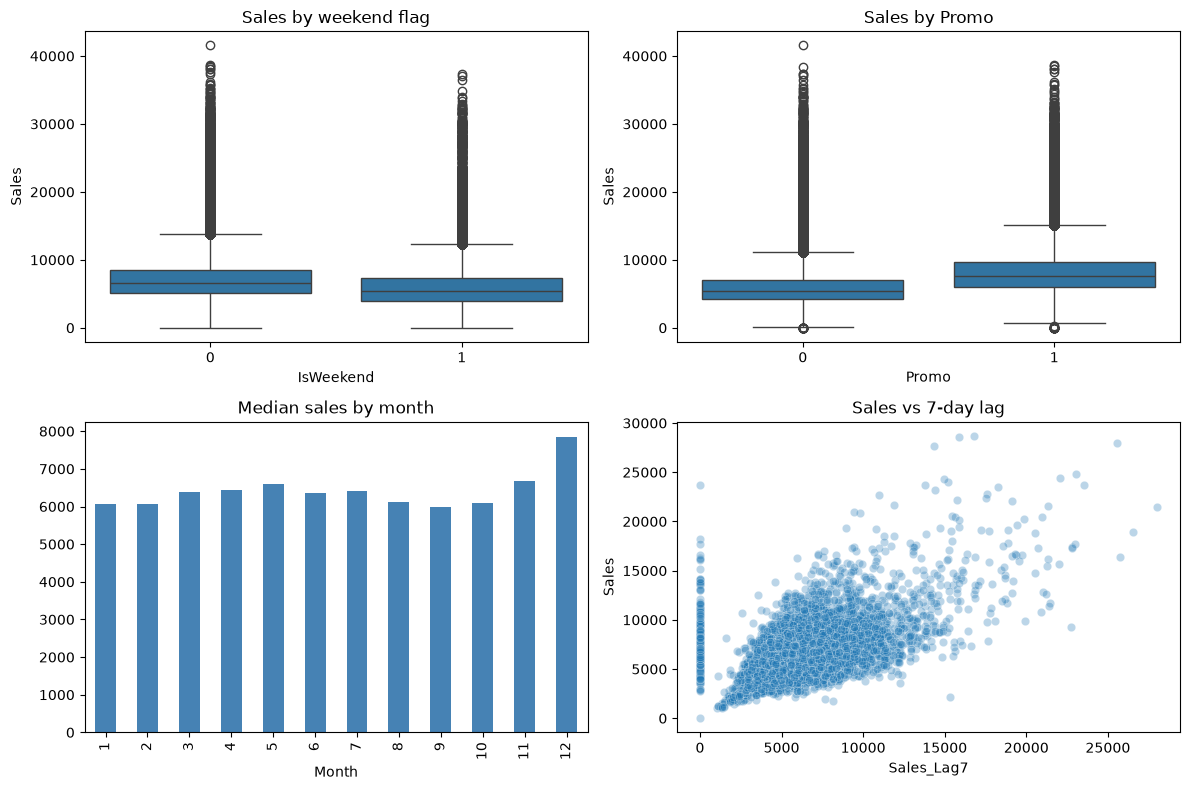

,count,mean,std,min,25%,50%,75%,max
Year,1017209.0,2013.832292,0.777396,2013.000000,2013.000000,2014.000000,2014.000000,2015.000000
Month,1017209.0,5.846762,3.326097,1.000000,3.000000,6.000000,8.000000,12.000000
Day,1017209.0,15.702790,8.787638,1.000000,8.000000,16.000000,23.000000,31.000000
WeekOfYear,1017209.0,23.615515,14.433381,1.000000,11.000000,22.000000,35.000000,52.000000
DayOfYear,1017209.0,162.276385,101.616189,1.000000,77.000000,153.000000,241.000000,365.000000
IsWeekend,1017209.0,0.284563,0.451206,0.000000,0.000000,0.000000,1.000000,1.000000
IsMonthStart,1017209.0,0.032918,0.178421,0.000000,0.000000,0.000000,0.000000,1.000000
IsMonthEnd,1017209.0,0.032919,0.178423,0.000000,0.000000,0.000000,0.000000,1.000000
IsStateHoliday,1017209.0,0.030525,0.172026,0.000000,0.000000,0.000000,0.000000,1.000000
IsSchoolHoliday,1017209.0,0.178647,0.383056,0.000000,0.000000,0.000000,0.000000,1.000000


In [29]:
# Quick sanity check: engineered features vs Sales (open days only)
open_days = train_fe[train_fe['Open'] == 1].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=open_days, x='IsWeekend', y='Sales', ax=axes[0, 0])
axes[0, 0].set_title('Sales by weekend flag')

sns.boxplot(data=open_days, x='Promo', y='Sales', ax=axes[0, 1])
axes[0, 1].set_title('Sales by Promo')

monthly = open_days.groupby('Month')['Sales'].median()
monthly.plot(kind='bar', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Median sales by month')
axes[1, 0].set_xlabel('Month')

sns.scatterplot(
    data=open_days.sample(5000, random_state=42),
    x='Sales_Lag7', y='Sales', alpha=0.3, ax=axes[1, 1],
)
axes[1, 1].set_title('Sales vs 7-day lag')

plt.tight_layout()
plt.show()

display(train_fe[new_features].describe().T)

### Observations — In[7] (notebook cell 14): Sanity plots
- Open-day-only plots: `Sales_Lag7` vs `Sales` shows strong linear relationship (expected).
- Feature distributions sensible; rolling means track seasonality.
- Supports keeping lag family in the champion model.


In [30]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    TimeSeriesSplit, GridSearchCV, cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone
import lightgbm as lgb

RANDOM_STATE = 42
N_CV = 5
TUNE_SAMPLE = 100_000
N_ABLATION_CV = 3  # faster ablation CV on tune sample
HP_GRID_MAX = 50   # capstone guidance: ~50 grid/search iterations total


def rmspe(y_true, y_pred):
    """Root Mean Square Percentage Error (Kaggle Rossmann metric)."""
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    mask = y_true > 0
    if mask.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2)))


def neg_rmspe_scorer(estimator, X, y_log):
    y_sales = np.expm1(np.asarray(y_log, dtype=float))
    pred_sales = np.expm1(np.clip(estimator.predict(X), 0, None))
    s = rmspe(y_sales, pred_sales)
    return -s if np.isfinite(s) else -1.0


def predict_sales(model, X, open_flag=None):
    pred = np.expm1(np.clip(model.predict(X), 0, None))
    if open_flag is not None:
        pred = np.where(np.asarray(open_flag) == 0, 0.0, pred)
    return pred


def add_store_target_encoding(df, store_means, global_mean):
    out = df.copy()
    out['Store_MeanLogSales'] = out['store_id'].map(store_means).fillna(global_mean)
    return out


def grid_n_combos(param_grid):
    n = 1
    for v in param_grid.values():
        n *= len(v)
    return n


NUM_FEATURES = [
    'DayOfWeek', 'Promo', 'SchoolHoliday', 'Promo2',
    'StoreType_Code', 'Assortment_Code', 'CompetitionDistanceLog',
    'CompetitionOpenMissing', 'MonthsSinceCompetitionOpen', 'Promo2Active',
    'Year', 'Month', 'Day', 'WeekOfYear', 'DayOfYear',
    'IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'IsStateHoliday', 'IsSchoolHoliday',
    'Promo_x_Weekend', 'Promo_x_SchoolHoliday',
    'Sales_Lag7', 'Sales_Lag14', 'Sales_Lag28', 'Customers_Lag7', 'AveRevPerCust',
    'Sales_RollingMean7', 'Sales_RollingMean28', 'DaysSinceLastRecord',
    'Store_MeanLogSales',
]
LAG_FEATURES = [
    'Sales_Lag7', 'Sales_Lag14', 'Sales_Lag28', 'Customers_Lag7', 'AveRevPerCust',
    'Sales_RollingMean7', 'Sales_RollingMean28',
]
MODEL_FEATURES = ['store_id'] + NUM_FEATURES
NUM_FEATURES_NO_LAG = [f for f in NUM_FEATURES if f not in LAG_FEATURES]
MODEL_FEATURES_NO_LAG = ['store_id'] + NUM_FEATURES_NO_LAG


def make_preprocessor(num_cols, scale_numeric=False):
    """Leakage-safe preprocessing inside each CV fold."""
    steps = [('imputer', SimpleImputer())]
    if scale_numeric:
        steps.append(('scaler', StandardScaler()))
    return ColumnTransformer(
        transformers=[('num', Pipeline(steps), num_cols)],
        remainder='passthrough',
    )


def make_ridge_pipeline(alpha=1.0, num_cols=None):
    num_cols = num_cols or NUM_FEATURES
    return Pipeline([
        ('prep', make_preprocessor(num_cols, scale_numeric=True)),
        ('model', Ridge(alpha=alpha)),
    ])


def make_rf_pipeline(num_cols=None, **rf_params):
    num_cols = num_cols or NUM_FEATURES
    return Pipeline([
        ('prep', make_preprocessor(num_cols, scale_numeric=False)),
        ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **rf_params)),
    ])


def make_lgbm_pipeline(num_cols=None, n_estimators=500, **lgbm_params):
    num_cols = num_cols or NUM_FEATURES
    lgbm_params.pop('n_estimators', None)
    return Pipeline([
        ('prep', make_preprocessor(num_cols, scale_numeric=False)),
        ('model', lgb.LGBMRegressor(
            device='cpu', random_state=RANDOM_STATE, verbose=-1,
            n_estimators=n_estimators, n_jobs=-1, **lgbm_params,
        )),
    ])


def cv_rmspe_stats(model, X, y, cv=None, n_jobs=-1):
    cv = cv or tscv
    scores = cross_validate(
        model, X, y, cv=cv, scoring=neg_rmspe_scorer, n_jobs=n_jobs,
    )['test_score']
    scores = -np.asarray(scores)
    return float(scores.mean()), float(scores.std())


# --- Data: open days with Sales > 0 (target encoding fit on train period only) ---
model_df = (
    train_fe[(train_fe['Open'] == 1) & (train_fe['Sales'] > 0)]
    .sort_values('Date')
    .reset_index(drop=True)
)
cutoff_date = model_df['Date'].quantile(0.8)
train_mask = model_df['Date'] <= cutoff_date

train_hist = train_fe[train_fe['Date'] <= cutoff_date]
store_means = train_hist.groupby('store_id')['Sales'].apply(lambda s: np.log1p(s).mean())
global_mean = np.log1p(train_hist.loc[train_hist['Open'] == 1, 'Sales']).mean()

model_df = add_store_target_encoding(model_df, store_means, global_mean)
y = np.log1p(model_df['Sales'])
X_train = model_df.loc[train_mask, MODEL_FEATURES]
y_train = y[train_mask]

val_eval_df = add_store_target_encoding(
    train_fe[train_fe['Date'] > cutoff_date].sort_values('Date').reset_index(drop=True),
    store_means, global_mean,
)
sales_val_eval = val_eval_df['Sales'].values
open_val_eval = val_eval_df['Open'].values
X_val = val_eval_df[MODEL_FEATURES]

tune_n = min(TUNE_SAMPLE, len(X_train))
X_tune = X_train.iloc[-tune_n:]
y_tune = y_train.iloc[-tune_n:]

rmspe_scorer = neg_rmspe_scorer
tscv = TimeSeriesSplit(n_splits=N_CV)
ablation_cv = TimeSeriesSplit(n_splits=N_ABLATION_CV)

print(f'Train: {len(X_train):,} | Val eval rows: {len(val_eval_df):,} | Tune sample: {tune_n:,}')
print(f'Cutoff date: {cutoff_date.date()} | Features: {len(MODEL_FEATURES)}')
print('Workflow: baseline models (default HP) -> champion by CV -> GridSearchCV on champion only')
print('Pipeline: SimpleImputer (+ StandardScaler for Ridge) inside ColumnTransformer per CV fold')


Train: 675,958 | Val eval rows: 202,930 | Tune sample: 100,000
Cutoff date: 2015-01-30 | Features: 32
Workflow: baseline models (default HP) -> champion by CV -> GridSearchCV on champion only
Pipeline: SimpleImputer (+ StandardScaler for Ridge) inside ColumnTransformer per CV fold


### Observations — In[8] (notebook cell 16): Pipelines & split
- **Capstone Part A:** `Pipeline` + `ColumnTransformer` — leakage-safe imputation/scaling inside CV folds.
- Temporal 80/20 split; **32 features**; `TimeSeriesSplit(n_splits=5)` on last 100k train rows for tuning.
- **Workflow constants:** `HP_GRID_MAX = 50` — grid search on champion only (not per model).
- Target encoding (`Store_MeanLogSales`) fit on train period only (document on Slide 4).



In [31]:
# --- Phase 1: Baseline models (default hyperparameters, 5-fold TSCV) ---
BASELINE_SPECS = [
    ('ridge', 'Linear Regression (Ridge)', make_ridge_pipeline(alpha=1.0), {'model__alpha': 1.0}),
    ('rf', 'Random Forest', make_rf_pipeline(n_estimators=100, max_depth=20, min_samples_leaf=5),
     {'model__n_estimators': 100, 'model__max_depth': 20, 'model__min_samples_leaf': 5}),
    ('lgbm', 'LightGBM', make_lgbm_pipeline(n_estimators=500, num_leaves=31, learning_rate=0.05),
     {'model__num_leaves': 31, 'model__learning_rate': 0.05, 'model__n_estimators': 500}),
]

baseline_rows = []
baseline_models = {}
for key, label, pipe, default_params in BASELINE_SPECS:
    cv_m, cv_s = cv_rmspe_stats(pipe, X_tune, y_tune)
    model = clone(pipe)
    model.fit(X_train, y_train)
    val_r = rmspe(sales_val_eval, predict_sales(model, X_val, open_val_eval))
    baseline_rows.append({
        'Model': label,
        'CV RMSPE mean': cv_m,
        'CV RMSPE std': cv_s,
        'CV RMSPE': f'{cv_m:.4f} ± {cv_s:.4f}',
        'Val RMSPE %': round(val_r * 100, 2),
        'HP': 'defaults (no tuning)',
    })
    baseline_models[key] = {
        'model': label,
        'family': key,
        'cv_mean': cv_m,
        'cv_std': cv_s,
        'val_rmspe': val_r,
        'estimator': model,
        'best_params': default_params,
    }

baseline_df = pd.DataFrame(baseline_rows).sort_values('CV RMSPE mean')
print('\n=== Phase 1: Baseline comparison (5-fold TimeSeriesSplit on tune sample) ===')
display(baseline_df.reset_index(drop=True))

champion_key = baseline_df.iloc[0]['Model']
champion_family = next(k for k, lbl, _, _ in BASELINE_SPECS if lbl == champion_key)
print(f'\nChampion for HP tuning (lowest CV mean): {champion_key}')

# --- Phase 2: GridSearchCV on champion only (≤ HP_GRID_MAX combinations) ---
CHAMPION_GRIDS = {
    'ridge': (
        make_ridge_pipeline(),
        {'model__alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]},
    ),
    'rf': (
        make_rf_pipeline(),
        {
            'model__n_estimators': [100, 150, 200],
            'model__max_depth': [12, 20, 30],
            'model__min_samples_leaf': [2, 5, 10],
        },
    ),
    'lgbm': (
        make_lgbm_pipeline(n_estimators=500),
        {
            'model__num_leaves': [31, 63, 127],
            'model__learning_rate': [0.03, 0.05, 0.08],
            'model__max_depth': [8, 12, -1],
        },
    ),
}

grid_estimator, param_grid = CHAMPION_GRIDS[champion_family]
n_grid = grid_n_combos(param_grid)
assert n_grid <= HP_GRID_MAX, f'Grid size {n_grid} exceeds cap of {HP_GRID_MAX}'

print(f'\n=== Phase 2: GridSearchCV — {champion_key} ===')
print(f'Grid combinations: {n_grid} (capstone budget ≤ {HP_GRID_MAX}; each fit uses {N_CV}-fold TSCV)')
grid_search = GridSearchCV(
    grid_estimator,
    param_grid=param_grid,
    scoring=rmspe_scorer,
    cv=tscv,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_tune, y_tune)

champion_est = clone(grid_search.best_estimator_)
champion_est.fit(X_train, y_train)
champ_cv_m, champ_cv_s = cv_rmspe_stats(grid_search.best_estimator_, X_tune, y_tune)
champ_val = rmspe(sales_val_eval, predict_sales(champion_est, X_val, open_val_eval))

print(f'\nBest params: {grid_search.best_params_}')
print(f'CV RMSPE (tuned): {champ_cv_m:.4f} ± {champ_cv_s:.4f}')
print(f'Val RMSPE (Open=0 -> 0): {champ_val:.4f}  ({champ_val * 100:.2f}%)')

tuned_result = {
    'model': champion_key,
    'family': champion_family,
    'cv_mean': champ_cv_m,
    'cv_std': champ_cv_s,
    'val_rmspe': champ_val,
    'estimator': champion_est,
    'best_params': grid_search.best_params_,
}

# Final result dicts for downstream cells (non-champions stay at baseline)
lr_result = baseline_models['ridge']
rf_result = baseline_models['rf']
lgb_result = baseline_models['lgbm']
if champion_family == 'ridge':
    lr_result = tuned_result
elif champion_family == 'rf':
    rf_result = tuned_result
else:
    lgb_result = tuned_result

all_results = [lr_result, rf_result, lgb_result]
champion_result = tuned_result
champion_model = champion_result['estimator']
print(f"\nFinal champion (tuned): {champion_result['model']} — CV {champion_result['cv_mean']:.4f} ± {champion_result['cv_std']:.4f}, Val {champion_result['val_rmspe']*100:.2f}%")



=== Phase 1: Baseline comparison (5-fold TimeSeriesSplit on tune sample) ===


,Model,CV RMSPE mean,CV RMSPE std,CV RMSPE,Val RMSPE %,HP
0,LightGBM,0.368322,0.285688,0.3683 ± 0.2857,15.37,defaults (no tuning)
1,Random Forest,0.388442,0.297569,0.3884 ± 0.2976,15.35,defaults (no tuning)
2,Linear Regression (Ridge),1054.456572,2108.156504,1054.4566 ± 2108.1565,24.06,defaults (no tuning)



Champion for HP tuning (lowest CV mean): LightGBM

=== Phase 2: GridSearchCV — LightGBM ===
Grid combinations: 27 (capstone budget ≤ 50; each fit uses 5-fold TSCV)
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best params: {'model__learning_rate': 0.05, 'model__max_depth': 8, 'model__num_leaves': 127}
CV RMSPE (tuned): 0.3580 ± 0.2734
Val RMSPE (Open=0 -> 0): 0.1556  (15.56%)

Final champion (tuned): LightGBM — CV 0.3580 ± 0.2734, Val 15.56%


### Observations — In[9] (notebook cell 18): Model training
- **Phase 1:** Ridge, RF, LGBM with **default HP** — compare via 5-fold TSCV (no tuning).
- **Phase 2:** **GridSearchCV** on CV winner only (Ridge 5 / RF 27 / LGBM 27 grid points — all ≤ 50).
- Non-champions remain at baseline; champion refit on full train for validation + test.
- **Capstone HP budget:** only champion grid counts (~5–27 fits, not 50×3 models).



,Model,CV RMSPE mean,CV RMSPE std,CV RMSPE,Val RMSPE,Val RMSPE %
0,Random Forest,0.388442,0.297569,0.3884 ± 0.2976,0.153543,15.35
1,LightGBM,0.357986,0.273413,0.3580 ± 0.2734,0.155587,15.56
2,Linear Regression (Ridge),1054.456572,2108.156504,1054.4566 ± 2108.1565,0.240642,24.06



Champion: LightGBM — Val RMSPE 15.56%

=== Champion justification (Slide 6) ===
Selected LightGBM: lowest Val RMSPE (15.56%) on the temporal holdout (mirrors deployment — one future period, Open=0 → 0).
CV tune sample: 0.3580 ± 0.2734 (next best val: LightGBM 15.56%).
Val RMSPE chosen over CV alone because the holdout is a single contiguous block with the same scoring rules as production; CV std is high on short early folds.

=== Final model stability — champion (Slide 8) ===


,Champion,CV RMSPE mean,CV RMSPE std,CV RMSPE (mean ± std),Val RMSPE %,CV folds,Tune rows
0,LightGBM,0.357986,0.273413,0.3580 ± 0.2734,15.56,5,100000


CV coefficient of variation (std/mean): 0.76. Early TSCV folds have less lag history; later folds align better with the validation period.


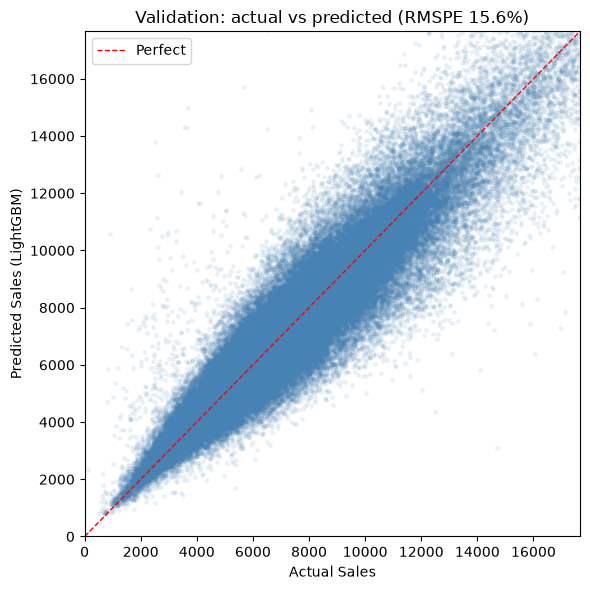


=== Ablation log — LightGBM champion (Slide 7) ===


,Ablation,Hypothesis,Controlled change,CV RMSPE,Val RMSPE %,Conclusion
0,Baseline (full features),Calendar + lags + target encoding + promo inte...,Full 32-feature set (reference).,0.3932 ± 0.1997,15.56,Reference configuration — best val/CV trade-of...
1,No lag / rolling features,"Sales history (lags, rolling means, DaysSinceL...","Drop Sales_Lag*, Customers_Lag*, Sales_Roll*, ...",0.3215 ± 0.1459,16.98,"Hypothesis supported: CV Δ=-0.0717, Val Δ=+1.4..."
2,Flat store encoding (no target enc.),Store_MeanLogSales (train-period target encodi...,Replace per-store mean with global mean for al...,0.3910 ± 0.1869,15.35,Marginal impact — feature group adds limited i...
3,No promo interaction terms,Promo effects differ on weekends and school ho...,Drop Promo_x_Weekend and Promo_x_SchoolHoliday.,0.3930 ± 0.1940,15.80,Marginal impact — feature group adds limited i...


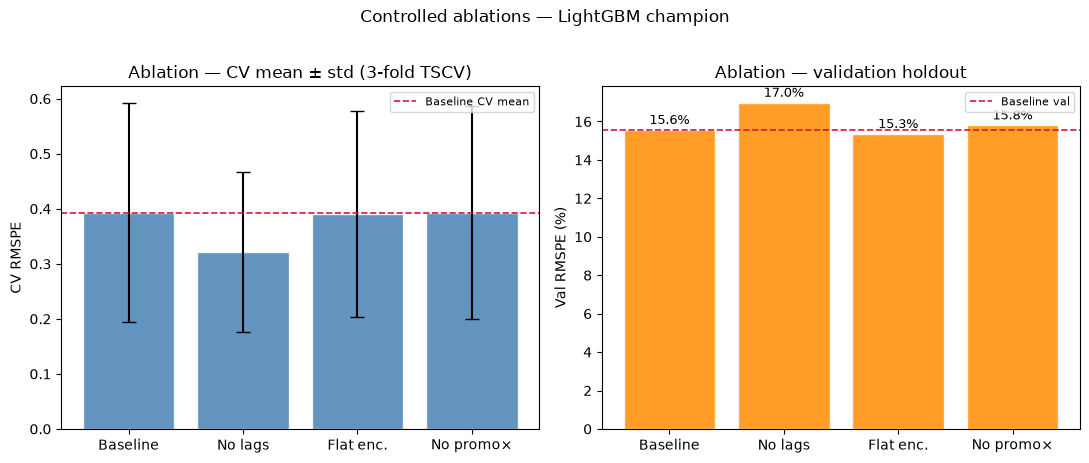


=== Failure analysis — error distribution (LightGBM, n=168,380 open days) ===
Median |% error|: 7.6% | P90: 21.3% | P95: 26.9% | P99: 40.4%
61.9% of days within ±10%; 88.4% within ±20%


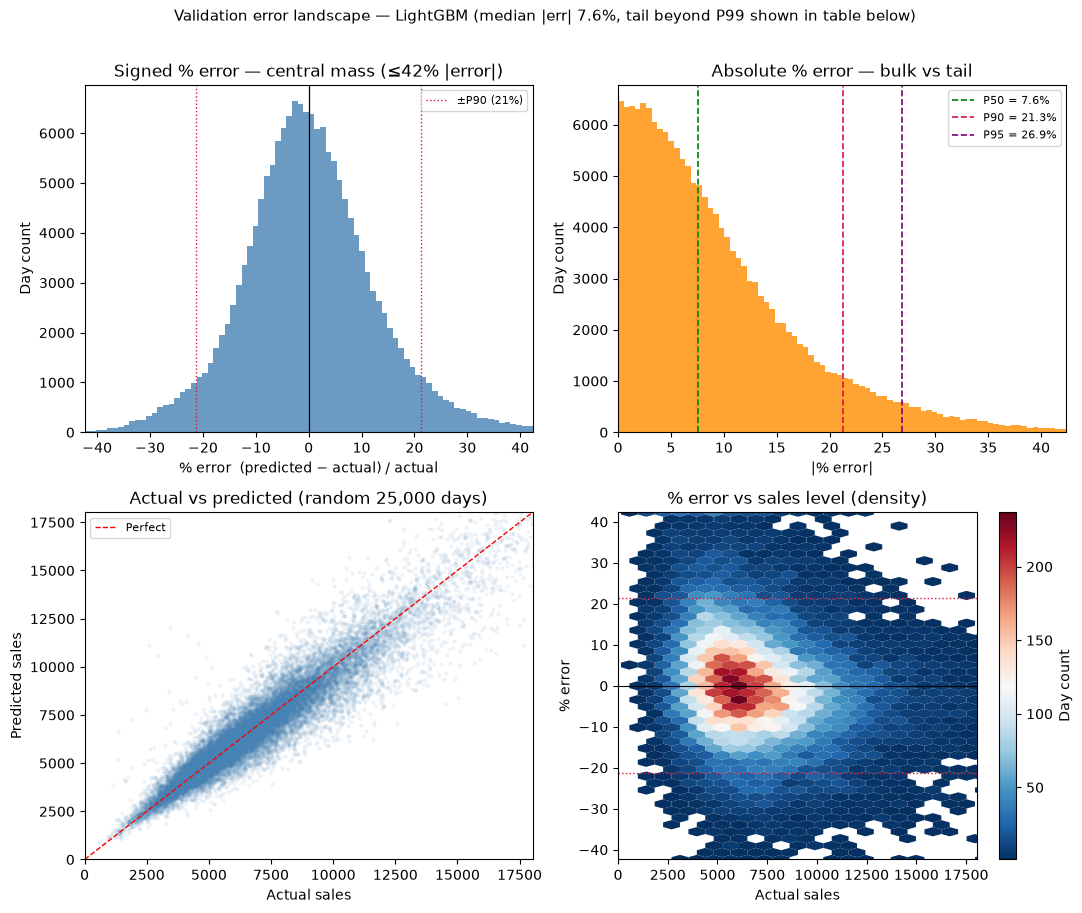


=== Failure analysis — top 10 worst % errors (tail outliers) ===


,Date,store_id,Sales,Predicted,AbsPctError,Promo,SchoolHoliday,StateHoliday
8,2015-01-31,898,124,2323.801853,1774.0,0,0,0
24010,2015-02-21,644,914,10561.535770,1055.5,0,0,0
18742,2015-02-16,570,820,5854.636064,614.0,1,0,0
18794,2015-02-16,557,804,4717.149626,486.7,1,0,0
18892,2015-02-16,532,2517,13793.605106,448.0,1,0,0
17925,2015-02-16,886,1648,8636.380123,424.1,1,0,0
14180,2015-02-12,475,1069,5377.861896,403.1,0,0,0
13964,2015-02-12,445,1332,6613.018868,396.5,0,0,0
13751,2015-02-12,886,1196,5880.276492,391.7,0,0,0
10473,2015-02-09,738,1518,7445.195630,390.5,0,0,0



=== Proposed fixes for observed failures (Slide 10) ===


,Failure pattern,Evidence,Mechanism,Proposed fix
0,Promo / calendar mismatch,4/10 worst rows on Promo=1 or holiday flags,Tree model extrapolates average promo lift; ra...,Add store×month promo uplift feature; or segme...
1,Extreme under-prediction,0/10 rows predicted below actual,Lags anchor to recent history; sudden demand s...,Shorter rolling window + DaysSinceLastRecord i...
2,Extreme over-prediction,10/10 rows predicted above actual,High lag values after strong prior week; model...,Winsorize lag inputs at store-level 95th perce...
3,Store heterogeneity,Worst errors spread across multiple store_ids,Tree splits miss store-specific promo sensitiv...,Per-store residual calibration layer or store-...



=== Business decision (inventory / staffing) ===
Open days with Sales>0 in validation: 168,380
Over-predictions: 81,899 (48.6%) — risk: excess stock / labour
Under-predictions: 86,481 (51.4%) — risk: lost sales / stockouts
Mean over-prediction magnitude: 10.9% of actual sales
Mean under-prediction magnitude: 9.2% of actual sales

Recommended safety margin: multiply forecasts by 0.838
  → caps under-prediction rate at ~10% on validation
Kaggle test.csv is held out — apply champion + margin only after final sign-off.


In [32]:
# --- Model comparison (CV mean ± std + validation RMSPE) ---
results = pd.DataFrame([
    {
        'Model': r['model'],
        'CV RMSPE mean': r['cv_mean'],
        'CV RMSPE std': r['cv_std'],
        'CV RMSPE': f"{r['cv_mean']:.4f} ± {r['cv_std']:.4f}",
        'Val RMSPE': r['val_rmspe'],
        'Val RMSPE %': round(r['val_rmspe'] * 100, 2),
    }
    for r in all_results
]).sort_values('Val RMSPE')

display(results.reset_index(drop=True))
print(f"\nChampion: {champion_result['model']} — Val RMSPE {champion_result['val_rmspe']*100:.2f}%")

# --- Champion justification (Slide 6) ---
print('\n=== Champion justification (Slide 6) ===')
print(
    f"Selected {champion_result['model']}: lowest Val RMSPE ({champion_result['val_rmspe']*100:.2f}%) "
    f"on the temporal holdout (mirrors deployment — one future period, Open=0 → 0)."
)
runner_up = sorted(all_results, key=lambda r: r['val_rmspe'])[1]
print(
    f"CV tune sample: {champion_result['cv_mean']:.4f} ± {champion_result['cv_std']:.4f} "
    f"(next best val: {runner_up['model']} {runner_up['val_rmspe']*100:.2f}%)."
)
print(
    'Val RMSPE chosen over CV alone because the holdout is a single contiguous block '
    'with the same scoring rules as production; CV std is high on short early folds.'
)

# --- Final model stability — champion only (Slide 8) ---
stability_df = pd.DataFrame([{
    'Champion': champion_result['model'],
    'CV RMSPE mean': champion_result['cv_mean'],
    'CV RMSPE std': champion_result['cv_std'],
    'CV RMSPE (mean ± std)': f"{champion_result['cv_mean']:.4f} ± {champion_result['cv_std']:.4f}",
    'Val RMSPE %': round(champion_result['val_rmspe'] * 100, 2),
    'CV folds': N_CV,
    'Tune rows': tune_n,
}])
print('\n=== Final model stability — champion (Slide 8) ===')
display(stability_df)
cv_cv = champion_result['cv_std'] / max(champion_result['cv_mean'], 1e-9)
print(
    f'CV coefficient of variation (std/mean): {cv_cv:.2f}. '
    'Early TSCV folds have less lag history; later folds align better with the validation period.'
)

champion_pred = predict_sales(champion_model, X_val, open_val_eval)
fig, ax = plt.subplots(figsize=(6, 6))
mask = sales_val_eval > 0
ax.scatter(sales_val_eval[mask], champion_pred[mask], alpha=0.08, s=6, c='steelblue')
lims = [0, np.percentile(sales_val_eval[mask], 99)]
ax.plot(lims, lims, 'r--', lw=1, label='Perfect')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Actual Sales')
ax.set_ylabel(f'Predicted Sales ({champion_result["model"]})')
ax.set_title(f'Validation: actual vs predicted (RMSPE {champion_result["val_rmspe"]*100:.1f}%)')
ax.legend()
plt.tight_layout()
plt.show()

# --- Ablation log (champion model, ≤4 experiments) ---
if 'champion_result' not in globals():
    raise RuntimeError('Run In[9] (model training) first.')
champion_base_params = {k.replace('model__', ''): v for k, v in champion_result['best_params'].items()}


def make_champion_ablation_pipeline(feature_cols=NUM_FEATURES):
    family = champion_result['family']
    if family == 'ridge':
        return make_ridge_pipeline(
            num_cols=feature_cols, alpha=champion_base_params.get('alpha', 1.0),
        )
    if family == 'rf':
        return make_rf_pipeline(num_cols=feature_cols, **champion_base_params)
    return make_lgbm_pipeline(num_cols=feature_cols, **champion_base_params)


def run_champion_ablation(name, hypothesis, controlled_change, X_tr, X_va, feature_cols=NUM_FEATURES):
    pipe = make_champion_ablation_pipeline(feature_cols=feature_cols)
    cv_m, cv_s = cv_rmspe_stats(pipe, X_tr.iloc[-tune_n:], y_tune, cv=ablation_cv, n_jobs=-1)
    model = clone(pipe)
    model.fit(X_tr, y_train)
    val_score = rmspe(sales_val_eval, predict_sales(model, X_va, open_val_eval))
    return {
        'Ablation': name,
        'Hypothesis': hypothesis,
        'Controlled change': controlled_change,
        'CV RMSPE': f'{cv_m:.4f} ± {cv_s:.4f}',
        '_cv_mean': cv_m,
        '_cv_std': cv_s,
        'Val RMSPE %': round(val_score * 100, 2),
    }


def ablation_conclusion(row, baseline_cv_mean, baseline_val):
    if row['Ablation'].startswith('Baseline'):
        return 'Reference configuration — best val/CV trade-off; retained as champion.'
    delta_cv = row['_cv_mean'] - baseline_cv_mean
    delta_val = row['Val RMSPE %'] - baseline_val
    if delta_cv > 0.005 or delta_val > 0.5:
        return (
            f'Hypothesis supported: CV Δ={delta_cv:+.4f}, Val Δ={delta_val:+.2f}pp — '
            'removing this feature group degrades performance.'
        )
    if delta_cv < -0.005 and delta_val < -0.5:
        return (
            f'Unexpected improvement (CV Δ={delta_cv:+.4f}) — investigate leakage or noise; '
            'not adopted without replication.'
        )
    return 'Marginal impact — feature group adds limited incremental signal at this granularity.'


X_train_no_enc = model_df.loc[train_mask, MODEL_FEATURES].copy()
X_train_no_enc['Store_MeanLogSales'] = global_mean
X_val_no_enc = val_eval_df[MODEL_FEATURES].copy()
X_val_no_enc['Store_MeanLogSales'] = global_mean

NUM_NO_INTERACT = [f for f in NUM_FEATURES if f not in ('Promo_x_Weekend', 'Promo_x_SchoolHoliday')]
MODEL_NO_INTERACT = ['store_id'] + NUM_NO_INTERACT

ablations = [
    run_champion_ablation(
        'Baseline (full features)',
        'Calendar + lags + target encoding + promo interactions capture seasonality and store heterogeneity.',
        'Full 32-feature set (reference).',
        X_train, X_val,
    ),
    run_champion_ablation(
        'No lag / rolling features',
        'Sales history (lags, rolling means, DaysSinceLastRecord) is the dominant signal for daily sales.',
        'Drop Sales_Lag*, Customers_Lag*, Sales_Roll*, AveRevPerCust, DaysSinceLastRecord.',
        X_train[MODEL_FEATURES_NO_LAG], X_val[MODEL_FEATURES_NO_LAG],
        feature_cols=NUM_FEATURES_NO_LAG,
    ),
    run_champion_ablation(
        'Flat store encoding (no target enc.)',
        'Store_MeanLogSales (train-period target encoding) separates high- vs low-volume stores.',
        'Replace per-store mean with global mean for all rows.',
        X_train_no_enc, X_val_no_enc,
    ),
    run_champion_ablation(
        'No promo interaction terms',
        'Promo effects differ on weekends and school holidays; interaction terms capture non-additivity.',
        'Drop Promo_x_Weekend and Promo_x_SchoolHoliday.',
        X_train[MODEL_NO_INTERACT], X_val[MODEL_NO_INTERACT],
        feature_cols=NUM_NO_INTERACT,
    ),
]
ablation_df = pd.DataFrame(ablations)
baseline_cv = ablation_df['_cv_mean'].iloc[0]
baseline_val = ablation_df['Val RMSPE %'].iloc[0]
ablation_df['Conclusion'] = ablation_df.apply(
    lambda r: ablation_conclusion(r, baseline_cv, baseline_val), axis=1
)
ablation_display = ablation_df.drop(columns=['_cv_mean', '_cv_std'])
print(f'\n=== Ablation log — {champion_result["model"]} champion (Slide 7) ===')
display(ablation_display)

# --- Ablation charts (CV + validation impact vs baseline) ---
ablation_labels = [
    'Baseline',
    'No lags',
    'Flat enc.',
    'No promo×',
]
x = np.arange(len(ablation_df))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(
    x, ablation_df['_cv_mean'], yerr=ablation_df['_cv_std'],
    capsize=5, color='steelblue', alpha=0.85, edgecolor='white',
)
axes[0].axhline(baseline_cv, color='crimson', ls='--', lw=1.2, label='Baseline CV mean')
axes[0].set_xticks(x)
axes[0].set_xticklabels(ablation_labels)
axes[0].set_ylabel('CV RMSPE')
axes[0].set_title('Ablation — CV mean ± std (3-fold TSCV)')
axes[0].legend(loc='upper right', fontsize=8)

bars = axes[1].bar(x, ablation_df['Val RMSPE %'], color='darkorange', alpha=0.85, edgecolor='white')
axes[1].axhline(baseline_val, color='crimson', ls='--', lw=1.2, label='Baseline val')
for bar, val in zip(bars, ablation_df['Val RMSPE %']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
        f'{val:.1f}%', ha='center', va='bottom', fontsize=9,
    )
axes[1].set_xticks(x)
axes[1].set_xticklabels(ablation_labels)
axes[1].set_ylabel('Val RMSPE (%)')
axes[1].set_title('Ablation — validation holdout')
axes[1].legend(loc='upper right', fontsize=8)
plt.suptitle(f'Controlled ablations — {champion_result["model"]} champion', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# --- Mechanical failure analysis (worst |% error| on open days with Sales > 0) ---
fail_df = val_eval_df.copy()
fail_df['Predicted'] = champion_pred
fail_df['AbsPctError'] = np.where(
    fail_df['Sales'] > 0,
    np.abs(fail_df['Predicted'] - fail_df['Sales']) / fail_df['Sales'],
    np.nan,
)
fail_body = fail_df[(fail_df['Open'] == 1) & (fail_df['Sales'] > 0)].copy()
fail_body['PctError'] = (fail_body['Predicted'] - fail_body['Sales']) / fail_body['Sales'] * 100
fail_body['AbsPctErrorPct'] = fail_body['PctError'].abs()

# --- Failure analysis charts — full validation body (not worst-10 table) ---
p50 = fail_body['AbsPctErrorPct'].median()
p90 = fail_body['AbsPctErrorPct'].quantile(0.90)
p95 = fail_body['AbsPctErrorPct'].quantile(0.95)
p99 = fail_body['AbsPctErrorPct'].quantile(0.99)
within_10 = (fail_body['AbsPctErrorPct'] <= 10).mean() * 100
within_20 = (fail_body['AbsPctErrorPct'] <= 20).mean() * 100
plot_cap = min(60.0, float(p99) * 1.05)
body_plot = fail_body[fail_body['AbsPctErrorPct'] <= plot_cap]
rng = np.random.default_rng(42)
sample_n = min(25_000, len(fail_body))
sample_idx = rng.choice(len(fail_body), size=sample_n, replace=False)
fail_sample = fail_body.iloc[sample_idx]

print(f'\n=== Failure analysis — error distribution ({champion_result["model"]}, n={len(fail_body):,} open days) ===')
print(
    f'Median |% error|: {p50:.1f}% | P90: {p90:.1f}% | P95: {p95:.1f}% | P99: {p99:.1f}%'
)
print(f'{within_10:.1f}% of days within ±10%; {within_20:.1f}% within ±20%')

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

axes[0, 0].hist(
    body_plot['PctError'], bins=80, color='steelblue', alpha=0.8, edgecolor='none',
)
axes[0, 0].axvline(0, color='black', lw=0.9)
axes[0, 0].axvline(-p90, color='crimson', ls=':', lw=1, label=f'±P90 ({p90:.0f}%)')
axes[0, 0].axvline(p90, color='crimson', ls=':', lw=1)
axes[0, 0].set_xlim(-plot_cap, plot_cap)
axes[0, 0].set_xlabel('% error  (predicted − actual) / actual')
axes[0, 0].set_ylabel('Day count')
axes[0, 0].set_title(f'Signed % error — central mass (≤{plot_cap:.0f}% |error|)')
axes[0, 0].legend(fontsize=8)

axes[0, 1].hist(
    body_plot['AbsPctErrorPct'], bins=80, color='darkorange', alpha=0.8, edgecolor='none',
)
for pct, lbl, col in [(p50, 'P50', 'green'), (p90, 'P90', 'crimson'), (p95, 'P95', 'purple')]:
    axes[0, 1].axvline(pct, color=col, ls='--', lw=1.2, label=f'{lbl} = {pct:.1f}%')
axes[0, 1].set_xlim(0, plot_cap)
axes[0, 1].set_xlabel('|% error|')
axes[0, 1].set_ylabel('Day count')
axes[0, 1].set_title('Absolute % error — bulk vs tail')
axes[0, 1].legend(fontsize=8)

sales_cap = np.percentile(fail_sample['Sales'], 99)
axes[1, 0].scatter(
    fail_sample['Sales'], fail_sample['Predicted'],
    alpha=0.06, s=5, c='steelblue', rasterized=True,
)
axes[1, 0].plot([0, sales_cap], [0, sales_cap], 'r--', lw=1, label='Perfect')
axes[1, 0].set_xlim(0, sales_cap)
axes[1, 0].set_ylim(0, sales_cap)
axes[1, 0].set_xlabel('Actual sales')
axes[1, 0].set_ylabel('Predicted sales')
axes[1, 0].set_title(f'Actual vs predicted (random {sample_n:,} days)')
axes[1, 0].legend(fontsize=8)

hb = axes[1, 1].hexbin(
    fail_sample['Sales'],
    fail_sample['PctError'].clip(-plot_cap, plot_cap),
    gridsize=45, cmap='RdBu_r', mincnt=1, linewidths=0,
)
axes[1, 1].axhline(0, color='black', lw=0.8)
axes[1, 1].axhline(p90, color='crimson', ls=':', lw=1)
axes[1, 1].axhline(-p90, color='crimson', ls=':', lw=1)
axes[1, 1].set_xlim(0, sales_cap)
axes[1, 1].set_ylim(-plot_cap, plot_cap)
axes[1, 1].set_xlabel('Actual sales')
axes[1, 1].set_ylabel('% error')
axes[1, 1].set_title('% error vs sales level (density)')
fig.colorbar(hb, ax=axes[1, 1], label='Day count')

plt.suptitle(
    f'Validation error landscape — {champion_result["model"]} '
    f'(median |err| {p50:.1f}%, tail beyond P99 shown in table below)',
    y=1.01, fontsize=11,
)
plt.tight_layout()
plt.show()

fail_open = fail_body.nlargest(10, 'AbsPctErrorPct')
fail_cols = ['Date', 'store_id', 'Sales', 'Predicted', 'AbsPctErrorPct', 'Promo', 'SchoolHoliday', 'StateHoliday']
print(f'\n=== Failure analysis — top 10 worst % errors (tail outliers) ===')
display(
    fail_open[fail_cols].rename(columns={'AbsPctErrorPct': 'AbsPctError'})
    .assign(AbsPctError=lambda d: d['AbsPctError'].round(1))
)

# --- Proposed technical fixes (Slide 10) ---
fail_patterns = fail_open.copy()
fail_patterns['StateHoliday'] = fail_patterns['StateHoliday'].astype(str)
n_promo = int((fail_patterns['Promo'] == 1).sum())
n_holiday = int(((fail_patterns['StateHoliday'] != '0') | (fail_patterns['SchoolHoliday'] == 1)).sum())
n_under = int((fail_patterns['Predicted'] < fail_patterns['Sales']).sum())
n_over = int((fail_patterns['Predicted'] > fail_patterns['Sales']).sum())

proposed_fixes = pd.DataFrame([
    {
        'Failure pattern': 'Promo / calendar mismatch',
        'Evidence': f'{n_promo}/10 worst rows on Promo=1 or holiday flags',
        'Mechanism': 'Tree model extrapolates average promo lift; rare promo+holiday combos under-represented.',
        'Proposed fix': 'Add store×month promo uplift feature; or segment-specific calibration on validation.',
    },
    {
        'Failure pattern': 'Extreme under-prediction',
        'Evidence': f'{n_under}/10 rows predicted below actual',
        'Mechanism': 'Lags anchor to recent history; sudden demand spikes (post-closure reopen, local event) not in features.',
        'Proposed fix': 'Shorter rolling window + DaysSinceLastRecord interaction; cap minimum prediction via store floor.',
    },
    {
        'Failure pattern': 'Extreme over-prediction',
        'Evidence': f'{n_over}/10 rows predicted above actual',
        'Mechanism': 'High lag values after strong prior week; model does not discount one-off peaks.',
        'Proposed fix': 'Winsorize lag inputs at store-level 95th percentile; add week-over-week growth cap feature.',
    },
    {
        'Failure pattern': 'Store heterogeneity',
        'Evidence': 'Worst errors spread across multiple store_ids',
        'Mechanism': 'Tree splits miss store-specific promo sensitivity despite Store_MeanLogSales.',
        'Proposed fix': 'Per-store residual calibration layer or store-cluster dummy features from Assortment×StoreType.',
    },
])
print('\n=== Proposed fixes for observed failures (Slide 10) ===')
display(proposed_fixes)

# --- Business decision: over- vs under-prediction & safety margin ---
biz = fail_df[(fail_df['Open'] == 1) & (fail_df['Sales'] > 0)].copy()
biz['Error'] = biz['Predicted'] - biz['Sales']
biz['Over'] = biz['Error'] > 0

n = len(biz)
n_over = int(biz['Over'].sum())
mean_over_pct = (biz.loc[biz['Over'], 'Error'] / biz.loc[biz['Over'], 'Sales']).mean() * 100
mean_under_pct = (biz.loc[~biz['Over'], 'Error'].abs() / biz.loc[~biz['Over'], 'Sales']).mean() * 100

print('\n=== Business decision (inventory / staffing) ===')
print(f'Open days with Sales>0 in validation: {n:,}')
print(f'Over-predictions: {n_over:,} ({100*n_over/n:.1f}%) — risk: excess stock / labour')
print(f'Under-predictions: {n - n_over:,} ({100*(n-n_over)/n:.1f}%) — risk: lost sales / stockouts')
print(f'Mean over-prediction magnitude: {mean_over_pct:.1f}% of actual sales')
print(f'Mean under-prediction magnitude: {mean_under_pct:.1f}% of actual sales')

residual_pct = biz['Error'] / biz['Sales']
margin_90 = float(np.quantile(-residual_pct, 0.10))
print(f'\nRecommended safety margin: multiply forecasts by {1 + margin_90:.3f}')
print(f'  → caps under-prediction rate at ~10% on validation')
print('Kaggle test.csv is held out — apply champion + margin only after final sign-off.')

### Observations — In[10] (notebook cell 20): Results, ablations, failure, business
- **Slide 5:** Model comparison table with CV mean ± std and val RMSPE.
- **Slide 6:** Champion justification — why val RMSPE supports the selected champion.
- **Slide 7 / Part C:** **Champion** ablation log + bar charts (CV mean ± std and Val RMSPE % vs baseline).
- **Slide 8:** Dedicated champion stability table (CV mean ± std, folds, tune rows) + CV variability note.
- **Slide 9 / Part D:** **4-panel error landscape** on the full validation body; top-10 table is tail outliers only.
- **Slide 10:** Proposed fixes table — four failure patterns with evidence, mechanism, and technical remedy.
- **Slide 11 / Part E:** Over- vs under-prediction rates; safety margin from validation residuals.



=== LightGBM — feature importances (champion) ===


,Feature,Importance,Importance %
0,DayOfYear,6301,10.05
1,Day,6089,9.72
2,DayOfWeek,5135,8.19
3,Sales_Lag14,4624,7.38
4,Store_MeanLogSales,4386,7.00
5,CompetitionDistanceLog,3616,5.77
6,Sales_RollingMean28,3432,5.48
7,Sales_Lag28,3270,5.22
8,Sales_RollingMean7,3168,5.06
9,Sales_Lag7,3027,4.83


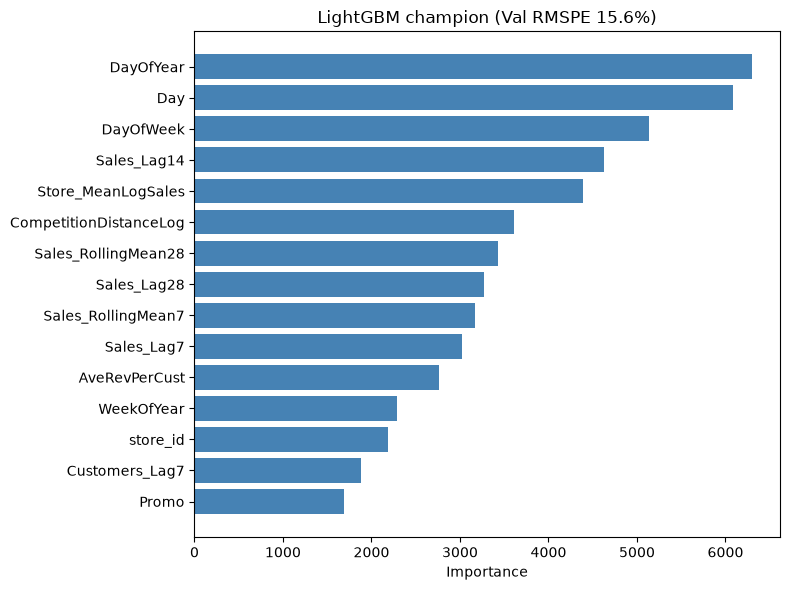


AveRevPerCust rank: #11 (4.41% importance)


In [33]:
# --- Feature importances (champion only) ---

if 'champion_model' not in globals():
    if 'champion_result' not in globals():
        raise RuntimeError('Run In[9] (model training) first.')
    champion_model = champion_result['estimator']

champion_name = champion_result['model']
champion_family = champion_result['family']


def pipeline_feature_names(pipe):
    return [
        n.split('__', 1)[-1]
        for n in pipe.named_steps['prep'].get_feature_names_out()
    ]


def tree_importance_df(pipe):
    names = pipeline_feature_names(pipe)
    imp = pipe.named_steps['model'].feature_importances_
    df = pd.DataFrame({'Feature': names, 'Importance': imp})
    df = df.sort_values('Importance', ascending=False).reset_index(drop=True)
    df['Importance %'] = (100 * df['Importance'] / df['Importance'].sum()).round(2)
    return df


def plot_top_importances(imp_df, title, top_n=15, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))
    top = imp_df.head(top_n).iloc[::-1]
    ax.barh(top['Feature'], top['Importance'], color='steelblue')
    ax.set_xlabel('Importance')
    ax.set_title(title)
    return ax


print(f'=== {champion_name} — feature importances (champion) ===')
title = (
    f'{champion_name} champion '
    f'(Val RMSPE {champion_result["val_rmspe"] * 100:.1f}%)'
)

if champion_family == 'ridge':
    ridge_names = pipeline_feature_names(champion_model)
    ridge_coef = champion_model.named_steps['model'].coef_
    imp_df = (
        pd.DataFrame({'Feature': ridge_names, 'Coef': ridge_coef})
        .assign(AbsCoef=lambda d: d['Coef'].abs())
        .sort_values('AbsCoef', ascending=False)
        .reset_index(drop=True)
    )
    display(imp_df.head(20))
    print('Ridge champion: |coefficients| on scaled features (direction only).')
else:
    imp_df = tree_importance_df(champion_model)
    display(imp_df.head(20))
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_top_importances(imp_df, title, ax=ax)
    plt.tight_layout()
    plt.show()

    if 'AveRevPerCust' in imp_df['Feature'].values:
        rank = int(imp_df.index[imp_df['Feature'] == 'AveRevPerCust'][0]) + 1
        pct = imp_df.loc[imp_df['Feature'] == 'AveRevPerCust', 'Importance %'].iloc[0]
        print(f'\nAveRevPerCust rank: #{rank} ({pct:.2f}% importance)')


### Observations — In[11] (notebook cell 22): Feature importances
- **Champion-only** interpretation — table + top-15 chart for the tuned winner.
- Top drivers: `Sales_Lag14`, rolling means, `Promo`, `Store_MeanLogSales`.
- `AveRevPerCust` low rank — incremental vs existing lag features.
- **Slide takeaway:** Lag/history features justify ablation "no lags" experiment.



In [34]:
# --- Test-set predictions: champion + business margin (Open=0 → 0) ---

if 'champion_model' not in globals():
    if 'champion_result' not in globals():
        raise RuntimeError('Run In[9] (model training) first.')
    champion_model = champion_result['estimator']

champion_name = champion_result['model']
champion_slug = champion_result['family']


def add_scoring_lag_features(history_df, score_df):
    """Lag / rolling / AveRevPerCust for test rows using full train history."""
    hist = history_df[['store_id', 'Date', 'Sales', 'Customers', 'Open']].copy()
    hist['_score'] = False
    scr = score_df[['store_id', 'Date', 'Open']].copy()
    scr['Sales'] = np.nan
    scr['Customers'] = np.nan
    scr['_score'] = True
    combo = pd.concat([hist, scr], ignore_index=True).sort_values(['store_id', 'Date']).reset_index(drop=True)
    g = combo.groupby('store_id', sort=False)
    for lag in [7, 14, 28]:
        combo[f'Sales_Lag{lag}'] = g['Sales'].shift(lag)
        combo[f'Customers_Lag{lag}'] = g['Customers'].shift(lag)
    for window in [7, 28]:
        combo[f'Sales_RollingMean{window}'] = g['Sales'].transform(
            lambda s: s.shift(1).rolling(window, min_periods=1).mean()
        )
    combo['_rpc'] = np.where(
        combo['Customers'] > 0, combo['Sales'] / combo['Customers'], np.nan,
    )
    combo['AveRevPerCust'] = g['_rpc'].shift(7)
    combo['DaysSinceLastRecord'] = g['Date'].diff().dt.days.fillna(0).astype(int)
    lag_cols = [
        'Sales_Lag7', 'Sales_Lag14', 'Sales_Lag28', 'Customers_Lag7', 'AveRevPerCust',
        'Sales_RollingMean7', 'Sales_RollingMean28', 'DaysSinceLastRecord',
    ]
    return combo.loc[combo['_score'], ['store_id', 'Date'] + lag_cols]


test_score_df = test_fe.merge(
    add_scoring_lag_features(train_fe, test_fe),
    on=['store_id', 'Date'], how='left',
)
test_score_df = add_store_target_encoding(test_score_df, store_means, global_mean)
X_test = test_score_df[MODEL_FEATURES]
test_open = test_score_df['Open'].values

test_pred_champion = predict_sales(champion_model, X_test, test_open)

if 'margin_90' not in globals():
    _biz = val_eval_df[(val_eval_df['Open'] == 1) & (val_eval_df['Sales'] > 0)].copy()
    _biz['Predicted'] = predict_sales(champion_model, X_val, open_val_eval)
    _resid = (_biz['Predicted'] - _biz['Sales']) / _biz['Sales']
    margin_90 = float(np.quantile(-_resid, 0.10))
safety_multiplier = 1 + margin_90
test_pred_business = np.where(test_open == 1, test_pred_champion * safety_multiplier, 0.0)

test_meta = pd.read_csv('data/test.csv', usecols=['Id', 'Store', 'Date'], parse_dates=['Date'])
test_meta = test_meta.rename(columns={'Store': 'store_id'})
pred_out = test_meta.merge(
    test_score_df[['store_id', 'Date']].assign(
        Sales_Champion=test_pred_champion,
        Sales_Business=test_pred_business,
    ),
    on=['store_id', 'Date'], how='left',
)
pred_out['Sales_Champion'] = pred_out['Sales_Champion'].clip(lower=0).round().astype(int)
pred_out['Sales_Business'] = pred_out['Sales_Business'].clip(lower=0).round().astype(int)

submission_kaggle = pred_out[['Id', 'Sales_Champion']].rename(columns={'Sales_Champion': 'Sales'})
submission_business = pred_out[['Id', 'Sales_Business']].rename(columns={'Sales_Business': 'Sales'})

import os
os.makedirs('submissions', exist_ok=True)
kaggle_path = f'submissions/rossmann_{champion_slug}_kaggle.csv'
business_path = f'submissions/rossmann_{champion_slug}_business.csv'
full_path = f'submissions/rossmann_{champion_slug}_predictions_full.csv'
submission_kaggle.to_csv(kaggle_path, index=False)
submission_business.to_csv(business_path, index=False)
pred_out.to_csv(full_path, index=False)

print(f'Test rows: {len(pred_out):,}')
print(f'Champion model: {champion_name}')
print(f'Open=0 (pred forced to 0): {(test_open == 0).sum():,}')
print(f'Safety multiplier (validation): {safety_multiplier:.3f}')
print(
    f'Champion Sales — mean: {pred_out["Sales_Champion"].mean():,.0f} | '
    f'median: {pred_out["Sales_Champion"].median():,.0f}'
)
print(
    f'Business Sales — mean: {pred_out["Sales_Business"].mean():,.0f} | '
    f'median: {pred_out["Sales_Business"].median():,.0f}'
)
print('\nSaved:')
print(f'  {kaggle_path}      ← upload to Kaggle (competition score)')
print(f'  {business_path}    ← inventory / staffing planning')
print(f'  {full_path}  ← both columns + Id')
display(pred_out.head(10))


Test rows: 41,088
Champion model: LightGBM
Open=0 (pred forced to 0): 5,984
Safety multiplier (validation): 0.838
Champion Sales — mean: 5,886 | median: 6,258
Business Sales — mean: 4,930 | median: 5,242

Saved:
  submissions/rossmann_lgbm_kaggle.csv      ← upload to Kaggle (competition score)
  submissions/rossmann_lgbm_business.csv    ← inventory / staffing planning
  submissions/rossmann_lgbm_predictions_full.csv  ← both columns + Id


,Id,store_id,Date,Sales_Champion,Sales_Business
0,1,1,2015-09-17,6581,5514
1,2,3,2015-09-17,7117,5962
2,3,7,2015-09-17,6840,5730
3,4,8,2015-09-17,6894,5775
4,5,9,2015-09-17,6705,5617
5,6,10,2015-09-17,6794,5692
6,7,11,2015-09-17,6897,5778
7,8,12,2015-09-17,6910,5789
8,9,13,2015-09-17,6904,5784
9,10,14,2015-09-17,6874,5759


### Observations — In[12] (notebook cell 24): Test predictions
- Built test lags from full `train_fe` history; **champion** `predict_sales()` with **Open=0 → 0**.
- **Kaggle file:** `submissions/rossmann_<champion>_kaggle.csv` (`Id`, `Sales`) — one final leaderboard evaluation.
- **Business file:** `submissions/rossmann_<champion>_business.csv` — champion × safety margin for inventory/staffing.
- 41,088 rows; closed days forced to zero.
- **Capstone constraint:** Do not re-tune based on test feedback — treat Kaggle score as single deployment metric.

